## ColliderML dataset

Refer to https://opendatadetector.github.io/ColliderML/ for details of the dataset and their exploration notebook https://github.com/OpenDataDetector/ColliderML/blob/main/notebooks/colliderml_loader_exploration.ipynb.

In this notebook, we install the colliderml package, download the dataset and explore the data a bit.

In [15]:
#%pip install colliderml

# also run in the install.sh in your venv for installing required packages

In [9]:
"""
downloading 100 events for ttbar and 100 for dihiggs in some cache directory

In below, adjust the argument --out /path/to/cache appropriately
"""

#!colliderml download --channels ttbar --pileup pu0 --objects calo_hits,particles --max-events 100 --out /Users/aneekphys/Downloads
#!colliderml download --channels dihiggs --pileup pu0 --objects calo_hits,particles --max-events 100 --out /Users/aneekphys/Downloads

'\ndownloading 100 events for ttbar and 100 for dihiggs in some cache directory\n\nIn below, adjust the argument --out /path/to/cache appropriately\n'

## Loading the dataset

In [5]:
"""
IMPORTS
"""

import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import numpy as np




import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import IterableDataset
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast



import h5py
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from livelossplot import PlotLosses




import sys

# adjust path to project properly

#PATH_TO_PROJECT = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek'
PATH_TO_PROJECT = '/Users/aneekphys/Documents/Other Research/hep-ssl'

sys.path.append(PATH_TO_PROJECT)


from src.data.dataset import ColliderMLHits
from src.data.coarsening import voxelize_hits
from src.data.augmentation import *


In [2]:


"""
Loading ColliderML data

"""

CACHE_DIR = '/Users/aneekphys/Downloads'

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 100,
    "data_dir":CACHE_DIR
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"][0:100]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events":100,
    "data_dir":CACHE_DIR
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"][0:100]



"""
some processing to create iterable datasets:

each instance is a dictionary with --> key 'calo_hit_features' giving hit features (of an entire event) of shape (num_hits, 4) with 
first 3 features (x,y,z) and the last feature being energy E.
"""

hits_ttbar = ColliderMLHits(calo_hits1, "train", shuffle_files=False, train_fraction=1.0)
hits_dihiggs = ColliderMLHits(calo_hits2, "train", shuffle_files=False, train_fraction=1.0)


## Example Usage

(9472, 4)


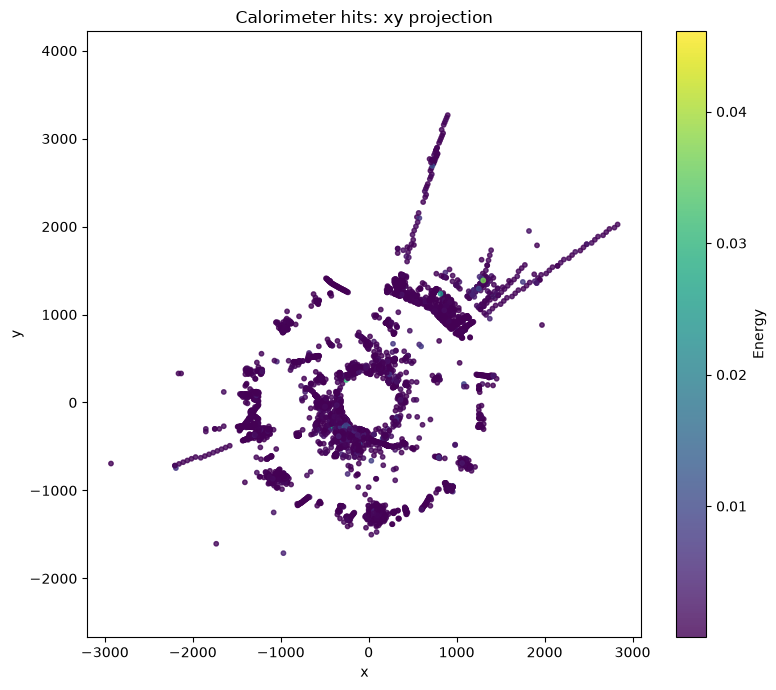

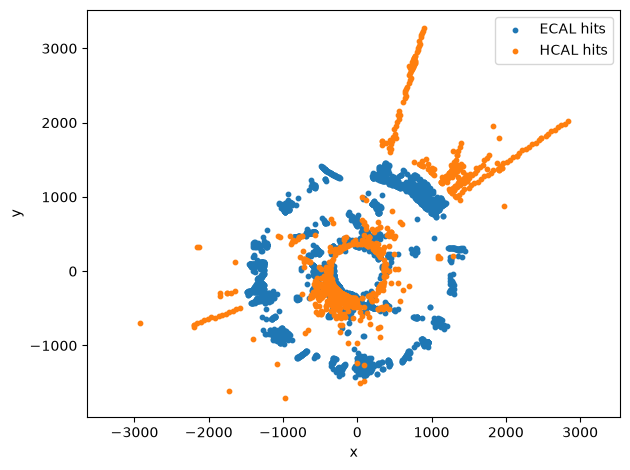

In [7]:
for hits in hits_ttbar:
    
    calo_hits = hits['calo_hit_features']
    
    ecal_mask = hits['ecal_mask']
    hcal_mask = hits['hcal_mask']
    
    print(calo_hits.shape) # output should be (num_hits, 4)
    
    
    """
    Accessing coordinates and energies
    """
    
    x_ = calo_hits[:,0]
    y_ = calo_hits[:,1]
    z_ = calo_hits[:,2]
    
    energy_ = calo_hits[:,3]
    
    
    """
    Plotting XY projection of calorimeter-hits
    """
    
    plt.figure(figsize=(8, 7))

    scatter = plt.scatter(
        x_,
        y_,
        c=energy_,
        s=10,
        cmap="viridis",
        alpha=0.8,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Calorimeter hits: xy projection")
    plt.axis("equal")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Energy")

    plt.tight_layout()
    plt.show()
    
    
    # Plotting ECAL hits and HCAL hits separately
    
    plt.figure()
    
    plt.scatter(x_[ecal_mask], y_[ecal_mask], s=10, label='ECAL hits')
    plt.scatter(x_[hcal_mask], y_[hcal_mask], s=10, label='HCAL hits')
    
    plt.legend()
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis("equal")
    
    plt.tight_layout()
    plt.show()
    
    
    
    break

In [12]:
"""
helper for plotting ecal and hcal hits
"""

import numpy as np
import matplotlib.pyplot as plt


def plot_calo_hit_projections(
    ecal_hits,
    hcal_hits,
    *,
    energy_weighted=True,
    marker_size_range=(5, 80),
    alpha=0.7,
    figsize=(18, 5),
    show=True,
):
    """
    Plot ECAL and HCAL hits in three coordinate projections:

        1. x-y
        2. eta-phi
        3. z-rho, where rho = sqrt(x^2 + y^2)

    Parameters
    ----------
    ecal_hits : array-like or torch.Tensor, shape (N_ecal, 4)
        ECAL hits with columns [x, y, z, E].

    hcal_hits : array-like or torch.Tensor, shape (N_hcal, 4)
        HCAL hits with columns [x, y, z, E].

    energy_weighted : bool, default=True
        If True, marker sizes are scaled according to hit energy.

    marker_size_range : tuple of float, default=(5, 80)
        Minimum and maximum marker sizes when energy_weighted=True.

    alpha : float, default=0.7
        Transparency of the scatter points.

    figsize : tuple, default=(18, 5)
        Size of the complete three-panel figure.

    show : bool, default=True
        Whether to call plt.show().

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created Matplotlib figure.

    axes : numpy.ndarray
        Array containing the three axes.
    """

    def to_numpy(hits, name):
        # Support PyTorch tensors without requiring torch as a dependency.
        if hasattr(hits, "detach"):
            hits = hits.detach().cpu().numpy()
        else:
            hits = np.asarray(hits)

        if hits.ndim != 2 or hits.shape[1] != 4:
            raise ValueError(
                f"{name} must have shape (N, 4), but received {hits.shape}."
            )

        return hits.astype(float, copy=False)

    def transform_hits(hits):
        x, y, z, energy = hits.T

        rho = np.sqrt(x**2 + y**2)
        phi = np.arctan2(y, x)

        # eta = asinh(z / rho), equivalent to
        # eta = -log(tan(theta / 2)).
        #
        # Clip rho only for numerical stability along the beam axis.
        eps = np.finfo(float).eps
        eta = np.arcsinh(z / np.maximum(rho, eps))

        return {
            "x": x,
            "y": y,
            "z": z,
            "rho": rho,
            "eta": eta,
            "phi": phi,
            "energy": energy,
        }

    def marker_sizes(energy):
        if not energy_weighted:
            return 15.0

        minimum_size, maximum_size = marker_size_range

        # Negative energies, if present due to preprocessing/noise,
        # should not produce invalid marker sizes.
        energy = np.clip(energy, a_min=0.0, a_max=None)

        if energy.size == 0:
            return np.array([])

        # log1p prevents a few energetic hits from completely dominating.
        scaled_energy = np.log1p(energy)
        energy_min = scaled_energy.min()
        energy_max = scaled_energy.max()

        if np.isclose(energy_min, energy_max):
            return np.full_like(
                scaled_energy,
                0.5 * (minimum_size + maximum_size),
            )

        normalized = (
            (scaled_energy - energy_min)
            / (energy_max - energy_min)
        )

        return minimum_size + normalized * (
            maximum_size - minimum_size
        )

    ecal_hits = to_numpy(ecal_hits, "ecal_hits")
    hcal_hits = to_numpy(hcal_hits, "hcal_hits")

    ecal = transform_hits(ecal_hits)
    hcal = transform_hits(hcal_hits)

    ecal_sizes = marker_sizes(ecal["energy"])
    hcal_sizes = marker_sizes(hcal["energy"])

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=figsize,
        constrained_layout=True,
    )

    plot_settings = [
        {
            "x_key": "x",
            "y_key": "y",
            "xlabel": r"$x$",
            "ylabel": r"$y$",
            "title": r"$x$-$y$ projection",
        },
        {
            "x_key": "eta",
            "y_key": "phi",
            "xlabel": r"$\eta$",
            "ylabel": r"$\phi$",
            "title": r"$\eta$-$\phi$ projection",
        },
        {
            "x_key": "z",
            "y_key": "rho",
            "xlabel": r"$z$",
            "ylabel": r"$\rho = \sqrt{x^2+y^2}$",
            "title": r"$z$-$\rho$ projection",
        },
    ]

    for ax, settings in zip(axes, plot_settings):
        ax.scatter(
            ecal[settings["x_key"]],
            ecal[settings["y_key"]],
            s=ecal_sizes,
            alpha=alpha,
            label="ECAL",
            edgecolors="none",
        )

        ax.scatter(
            hcal[settings["x_key"]],
            hcal[settings["y_key"]],
            s=hcal_sizes,
            alpha=alpha,
            label="HCAL",
            edgecolors="none",
        )

        ax.set_xlabel(settings["xlabel"])
        ax.set_ylabel(settings["ylabel"])
        ax.set_title(settings["title"])
        ax.grid(True, alpha=0.25)
        ax.legend()
        
    # Equal geometric scaling for physical-coordinate plots
    axes[0].set_aspect("equal", adjustable="datalim")
    #axes[2].set_aspect("equal", adjustable="datalim")

    # rho is non-negative
    axes[2].set_ylim(bottom=0)


    # Standard angular range for phi.
    axes[1].set_ylim(-np.pi, np.pi)
    axes[1].set_yticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        labels=[
            r"$-\pi$",
            r"$-\pi/2$",
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
        ],
    )

    if show:
        plt.show()

    return fig, axes

(9472, 4)


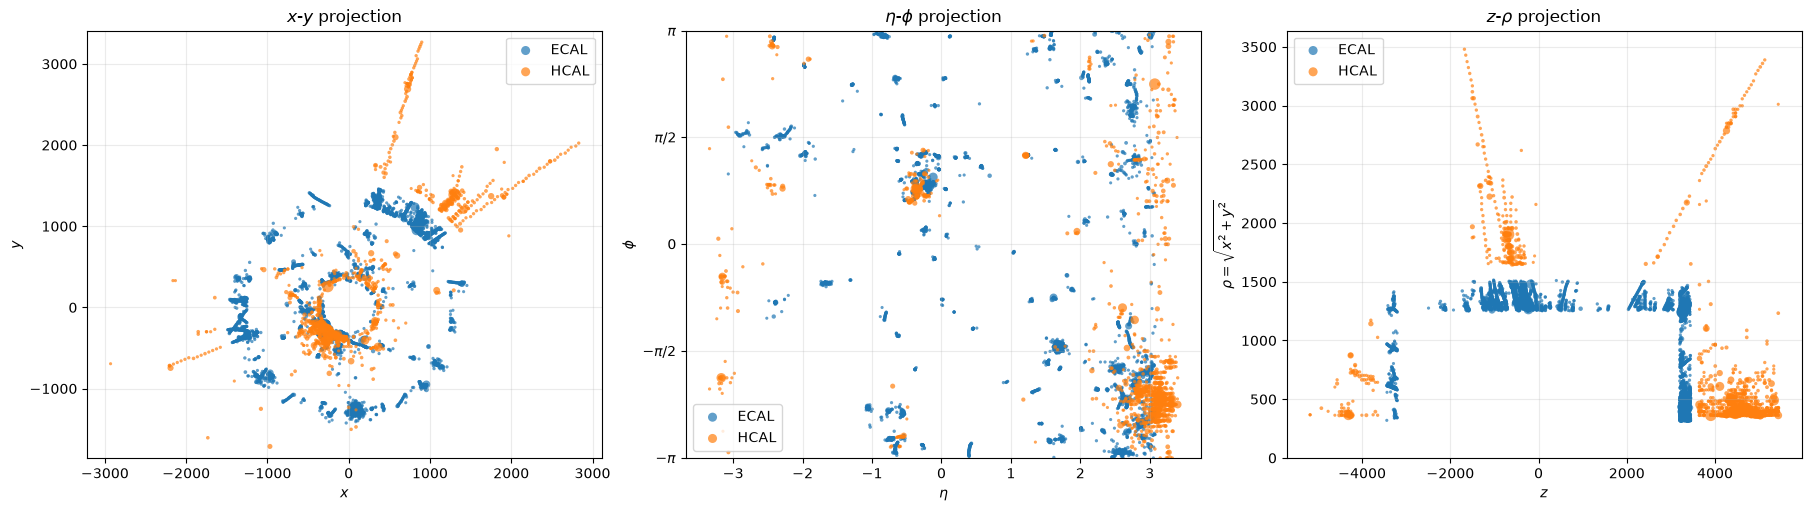

In [14]:
for hits in hits_ttbar:
    
    calo_hits = hits['calo_hit_features']
    
    ecal_mask = hits['ecal_mask']
    hcal_mask = hits['hcal_mask']
    
    print(calo_hits.shape) # output should be (num_hits, 4)
    
    
    ecal_hits = calo_hits[ecal_mask]
    hcal_hits = calo_hits[hcal_mask]
    
    fig, axes = plot_calo_hit_projections(
        ecal_hits,
        hcal_hits,
        energy_weighted=True,
        show=False,
    )
    
    
    
    fig.savefig("/Users/aneekphys/Documents/Other Research/hep-ssl/figures/calorimeter_ttbar_projections.png", bbox_inches="tight")
    
    plt.show()

    
    
    break

    
